In [14]:
# Từ dữ liệu chọn ra các cụm sử dụng K-Means Clustering
# 4 cột: pass data ...
#nếu dùng kmean thì chia làm bao nhiêu cluster là phù hợp
#giả sử đã biết 12 cột phải đc cluster; phải dùng thuật toán nào tốt nhất đẻ phân loại dữ liệu
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("clean_feature.csv")
df = df.dropna()
df = df.drop_duplicates()



In [16]:
X = df.loc[:,"count": "data"]
Y = df["ServiceID"]
X

,count,passed,period,data
0,2974,2974,63.952589,612.081036
1,4528,4528,63.000000,960.307862
2,19,19,62.000000,566.315789
3,1207,1207,63.000000,601.025684
4,8450,8450,63.942130,611.024024
...,...,...,...,...
450666,1,1,62.000000,624.000000
450667,108,108,62.000000,1075.972222
450668,5279,5279,63.000000,599.900170
450669,2,2,63.000000,1437.500000


[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


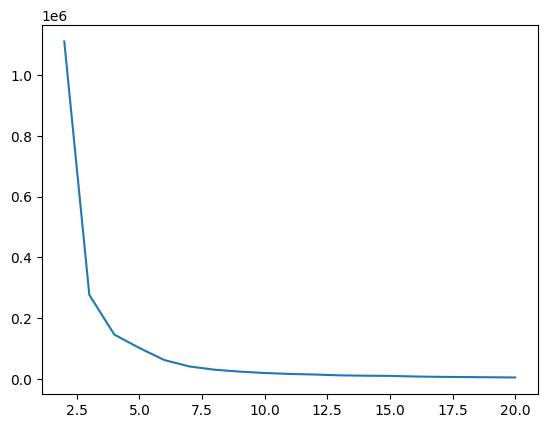

In [17]:
X1 = StandardScaler().fit_transform(X)
K= list(range(2,21))
print(K)


loss_s = []
for i in K:
    ute = KMeans(n_clusters=i)
    ute.fit(X1)
    loss_s.append(ute.inertia_)

    
plt.plot(K , loss_s)

In [18]:
# Huấn luyện mô hình KMeans với k=5
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X1)

# Bước 4: Gán nhãn cụm cho dữ liệu gốc
df['cluster'] = kmeans.labels_
df.head()


,Day,DoWeek,hour,count,passed,period,data,ServiceID,cluster
0,2021-12-29,2,17,2974,2974,63.952589,612.081036,2,4
1,2021-12-29,2,17,4528,4528,63.000000,960.307862,11,4
2,2021-12-29,2,17,19,19,62.000000,566.315789,5,0
3,2021-12-29,2,17,1207,1207,63.000000,601.025684,7,0
4,2021-12-29,2,18,8450,8450,63.942130,611.024024,2,2


In [19]:
from sklearn.decomposition import PCA

# Giảm từ 12 chiều xuống 2 chiều
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X1)

# Thêm kết quả PCA vào dataframe
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]


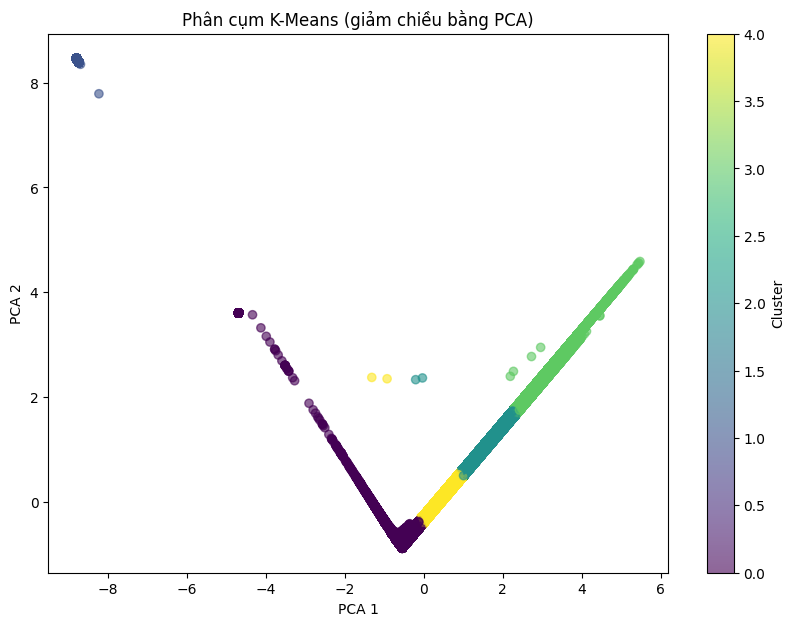

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.scatter(df['PCA1'], df['PCA2'], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Phân cụm K-Means (giảm chiều bằng PCA)')
plt.colorbar(label='Cluster')
plt.show()


In [21]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X1)
labels = gmm.predict(X1)


In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
labels = dbscan.fit_predict(X1)


In [ ]:
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method For Optimal k")
plt.show()
